--- Running t-SNE with different perplexity values ---
Calculating for perplexity = 5...


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Calculating for perplexity = 30...


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Calculating for perplexity = 50...


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Calculations complete.


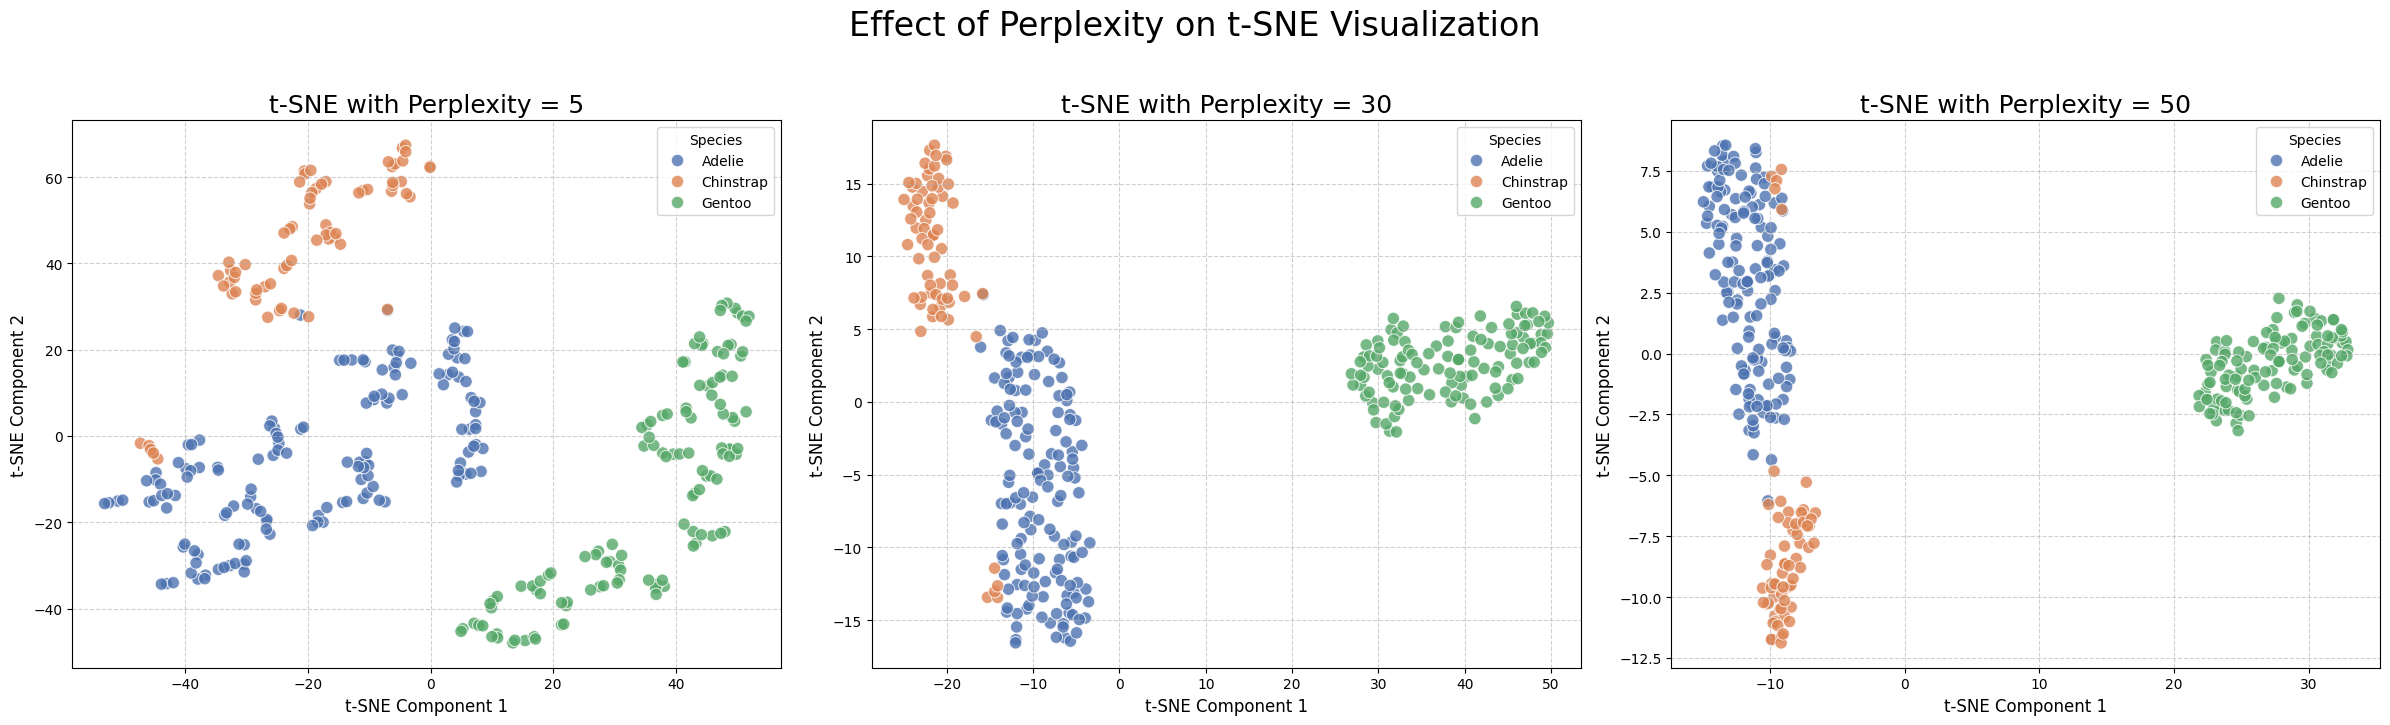

In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

# --- 1. Load, Prepare, and Clean Data (using aggressive imputation) ---
penguins_df = sns.load_dataset("penguins").dropna().reset_index(drop=True)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

X_scaled = StandardScaler().fit_transform(X)

# Using the aggressive outlier detection from the previous step
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(X_scaled)
outlier_indices = np.where(outlier_predictions == -1)[0]

penguins_imputed_df = penguins_df.copy()
species_means = penguins_df.groupby('species')[features].mean()
for idx in outlier_indices:
    outlier_species = penguins_imputed_df.loc[idx, 'species']
    imputation_values = species_means.loc[outlier_species]
    penguins_imputed_df.loc[idx, features] = imputation_values

X_imputed = penguins_imputed_df[features]
X_imputed_scaled = StandardScaler().fit_transform(X_imputed)

# --- 2. Run t-SNE with Different Perplexity Values ---
perplexity_values = [5, 30, 50]
tsne_results = {}

print("--- Running t-SNE with different perplexity values ---")
for p in perplexity_values:
    print(f"Calculating for perplexity = {p}...")
    tsne = TSNE(n_components=2, perplexity=p, random_state=42, n_iter=1000)
    tsne_components = tsne.fit_transform(X_imputed_scaled)

    tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE Component 1', 't-SNE Component 2'])
    tsne_df['species'] = y.values
    tsne_results[p] = tsne_df

print("Calculations complete.")

# --- 3. Visualize the Results Side-by-Side ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for i, p in enumerate(perplexity_values):
    ax = axes[i]
    data_to_plot = tsne_results[p]

    sns.scatterplot(
        x='t-SNE Component 1', y='t-SNE Component 2',
        hue='species', data=data_to_plot,
        palette='deep', s=80, alpha=0.8, ax=ax
    )

    ax.set_title(f't-SNE with Perplexity = {p}', fontsize=18)
    ax.set_xlabel('t-SNE Component 1', fontsize=12)
    ax.set_ylabel('t-SNE Component 2', fontsize=12)
    ax.legend(title='Species')
    ax.grid(True, linestyle='--', alpha=0.6)

fig.suptitle('Effect of Perplexity on t-SNE Visualization', fontsize=24, y=1.03)
plt.tight_layout()
plt.show()

--- AGGRESSIVE Outlier Imputation Workflow ---
Contamination level set to: 5%
Number of outliers detected: 17
[SUCCESS] 17 outliers have been replaced with their respective species' mean.


/Users/arincare/Web/ML-Assignment/.venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


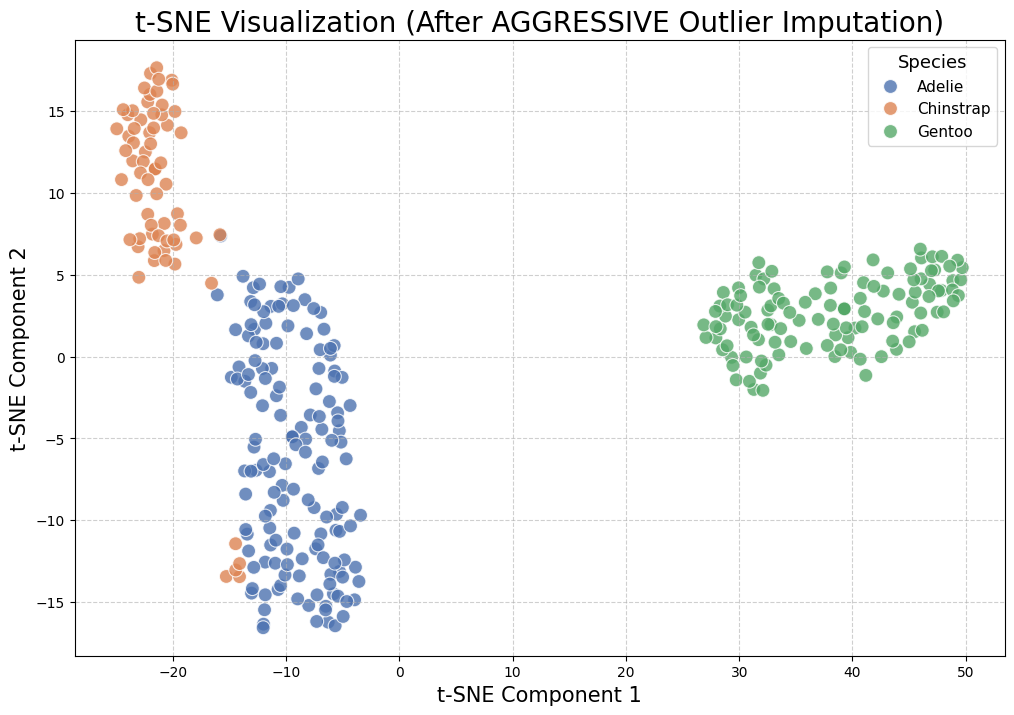

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest

# --- 1. Load and Prepare Data ---
penguins_df = sns.load_dataset("penguins").dropna().reset_index(drop=True)
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = penguins_df[features]
y = penguins_df['species']

X_scaled = StandardScaler().fit_transform(X)

# --- 2. Detect Outliers using a MORE AGGRESSIVE Isolation Forest ---
# [CHANGE] We are now manually setting the contamination level to 5% (0.05).
# This tells the model to be less conservative and flag more points as outliers.
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outlier_predictions = iso_forest.fit_predict(X_scaled)
outlier_indices = np.where(outlier_predictions == -1)[0]

print("--- AGGRESSIVE Outlier Imputation Workflow ---")
print(f"Contamination level set to: 5%")
print(f"Number of outliers detected: {len(outlier_indices)}")

# --- 3. Impute Outliers with Species-Specific Mean (Same as before) ---
penguins_imputed_df = penguins_df.copy()
species_means = penguins_df.groupby('species')[features].mean()

for idx in outlier_indices:
    outlier_species = penguins_imputed_df.loc[idx, 'species']
    imputation_values = species_means.loc[outlier_species]
    penguins_imputed_df.loc[idx, features] = imputation_values

print(f"[SUCCESS] {len(outlier_indices)} outliers have been replaced with their respective species' mean.")

# --- 4. Apply t-SNE on the IMPUTED data (Same as before) ---
X_imputed = penguins_imputed_df[features]
X_imputed_scaled = StandardScaler().fit_transform(X_imputed)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
tsne_components = tsne.fit_transform(X_imputed_scaled)

tsne_df = pd.DataFrame(data=tsne_components, columns=['t-SNE Component 1', 't-SNE Component 2'])
tsne_df['species'] = y.values

# --- 5. Visualize the t-SNE Results ---
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='t-SNE Component 1', y='t-SNE Component 2',
    hue='species', data=tsne_df,
    palette='deep', s=100, alpha=0.8
)

plt.title('t-SNE Visualization (After AGGRESSIVE Outlier Imputation)', fontsize=20)
plt.xlabel('t-SNE Component 1', fontsize=15)
plt.ylabel('t-SNE Component 2', fontsize=15)
plt.legend(title='Species', title_fontsize='13', fontsize='11')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()